# Data science jobs
Dataset is here: https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries

You should upload the CSV to the Colab: `w1_ds_salaries.csv`

In [50]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '{:,.0f}'.format(x) if int(x) == x else '{:,.3f}'.format(x))

In [51]:
df = pd.read_csv("w1_ds_salaries.csv")

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [53]:
# Remove the index column
df.drop(columns=['Unnamed: 0'], inplace=True)

In [54]:
# How many jobs are not full-time?
sum(df['employment_type'] != 'FT')

19

In [55]:
# Remove the non-full time jobs; then remove the redundant employment type column
df = df[df['employment_type'] == 'FT'].drop(columns=['employment_type'])

In [56]:
df.shape

(588, 10)

In [57]:
dup_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dup_count}")
print(f"Dataset rows: {len(df)}")
print(f"Duplicate percentage: {dup_count / len(df) * 100:.2f}%")

Exact duplicate rows: 42
Dataset rows: 588
Duplicate percentage: 7.14%


In [115]:
dupes = df.duplicated(keep='first')
specific_salary = df['salary'] % 1000 != 0
df = df[~(specific_salary & dupes)]  # remove 16 specific-salary duplicates
df_copy = df

In [59]:
df[df['company_location'] == 'US']['salary_in_usd'].min()
# 5679 min US salary, compared to 2859 for non-US

5679

In [60]:
check = (df['company_location'] == 'US') & (df['employee_residence'] == 'US')
df[check]['salary_in_usd'].min()

25000

In [61]:
df[df['salary_in_usd'] == 5679]

,work_year,experience_level,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
179,2021,MI,Data Scientist,420000,INR,5679,IN,100,US,S


In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,572,"2,021.404",0.692,"2,020","2,021","2,022","2,022","2,022"
salary,572,"336,899.951","1,589,900.613","4,000","70,000","115,717","165,000","30,400,000"
salary_in_usd,572,"113,130.677","70,087.707","2,859","63,831","103,080","150,000","600,000"
remote_ratio,572,70.542,41.027,0,50,100,100,100


In [63]:
df.columns

Index(['work_year', 'experience_level', 'job_title', 'salary',
       'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [64]:
df[df['salary_in_usd'] == df['salary_in_usd'].min()]

,work_year,experience_level,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
176,2021,MI,Data Scientist,58000,MXN,2859,MX,0,MX,S


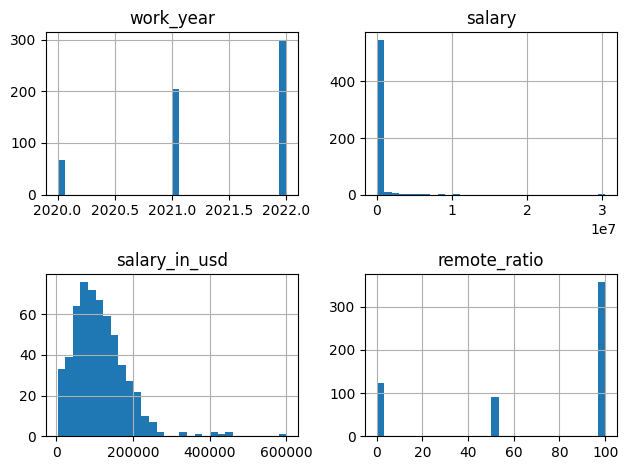

In [65]:
df.hist(bins=30)
plt.tight_layout()
plt.show()

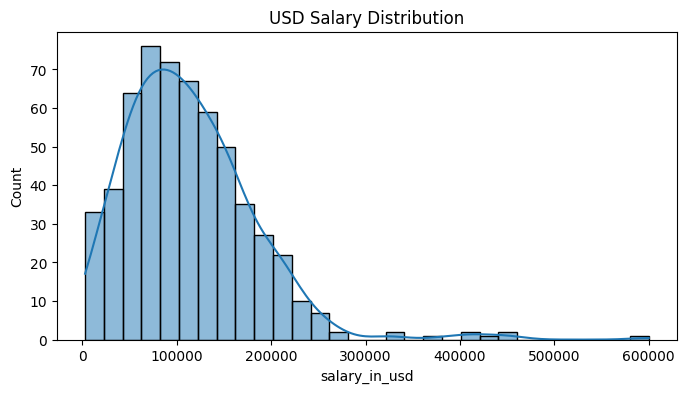

In [66]:
plt.figure(figsize=(8,4))
sns.histplot(df['salary_in_usd'], bins=30, kde=True)
plt.title("USD Salary Distribution")
plt.show()

In [67]:
# Large salary values seem reasonable
df[df['salary_in_usd'] >= 400000]

,work_year,experience_level,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
33,2020,MI,Research Scientist,450000,USD,450000,US,0,US,M
63,2020,SE,Data Scientist,412000,USD,412000,US,100,US,L
97,2021,MI,Financial Data Analyst,450000,USD,450000,US,100,US,L
157,2021,MI,Applied Machine Learning Scientist,423000,USD,423000,US,50,US,L
252,2021,EX,Principal Data Engineer,600000,USD,600000,US,100,US,L
523,2022,SE,Data Analytics Lead,405000,USD,405000,US,100,US,L


In [68]:
top_features = df.select_dtypes(exclude='number').columns

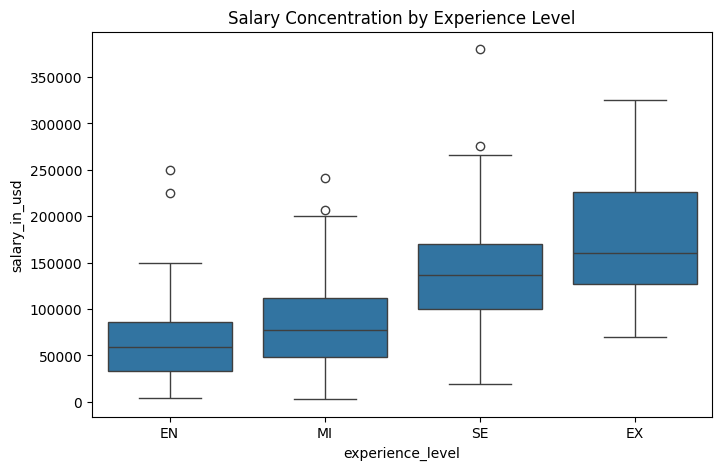

In [69]:
# QUESTION: How does experience affect salary?
dfx = df[df['salary_in_usd'] < 400000]  # remove outliers for graphing purposes
plt.figure(figsize=(8,5))
sns.boxplot(
    data=dfx,
    x='experience_level',
    y='salary_in_usd',
    order=['EN', 'MI', 'SE', 'EX']
)
plt.title('Salary Concentration by Experience Level')
plt.show()

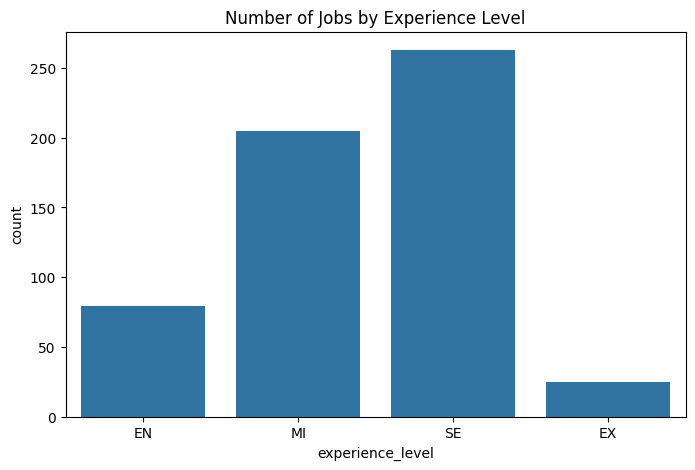

In [70]:
# QUESTION: Which experience level has the highest number of jobs
job_count = df['experience_level'].value_counts().reset_index()
job_count.columns = ['experience_level', 'count']  # call out column names
plt.figure(figsize=(8,5))
sns.barplot(
    data=job_count,
    x='experience_level',
    y='count',
    order=['EN','MI','SE','EX']
)
plt.title('Number of Jobs by Experience Level')
plt.show()

In [71]:
# Most common jobs are:
# * data scientist
# * data engineer
# * data analyst
# Afterwards come: machine learning engineer, research scientist, data science manager, data architect
# The rest have less than 10 counts in a total population of 607.
df['job_title'].value_counts().head()

,count
job_title,
Data Scientist,138
Data Engineer,125
Data Analyst,88
Machine Learning Engineer,39
Research Scientist,16


In [72]:
# Let's look at the following data only:
#   salary_in_usd, job_title, experience_level, employment_type, company_size
df[['salary_in_usd', 'job_title', 'experience_level', 'company_size']].head(10)

,salary_in_usd,job_title,experience_level,company_size
0,79833,Data Scientist,MI,L
1,260000,Machine Learning Scientist,SE,S
2,109024,Big Data Engineer,SE,M
3,20000,Product Data Analyst,MI,S
4,150000,Machine Learning Engineer,SE,L
5,72000,Data Analyst,EN,L
6,190000,Lead Data Scientist,SE,S
7,35735,Data Scientist,MI,L
8,135000,Business Data Analyst,MI,L
9,125000,Lead Data Engineer,SE,S


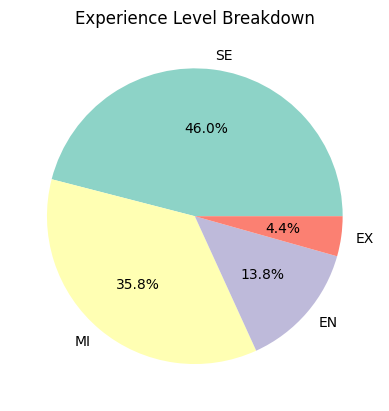

In [73]:
# The most common experience levels are SE and MI
counts = df['experience_level'].value_counts()
counts.plot.pie(
    autopct='%1.1f%%',
    colors=plt.cm.Set3.colors
)
plt.ylabel('')
plt.title("Experience Level Breakdown")
plt.show()

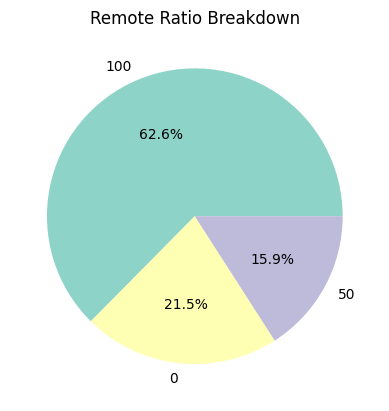

In [74]:
# Most employees are remote
counts = df['remote_ratio'].value_counts(normalize=True)
counts.plot.pie(
    autopct='%1.1f%%',
    colors=plt.cm.Set3.colors
)
plt.ylabel('')
plt.title("Remote Ratio Breakdown")
plt.show()

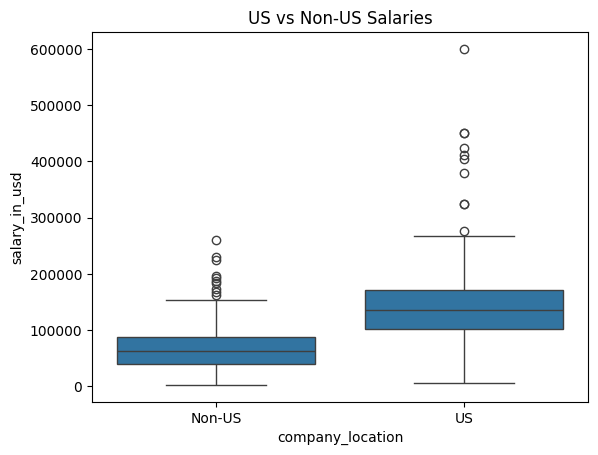

In [36]:
sns.boxplot(
    data=df,
    x=df['company_location'].apply(lambda x: 'US' if x == 'US' else 'Non-US'),
    y='salary_in_usd'
)
plt.title('US vs Non-US Salaries')
plt.show()

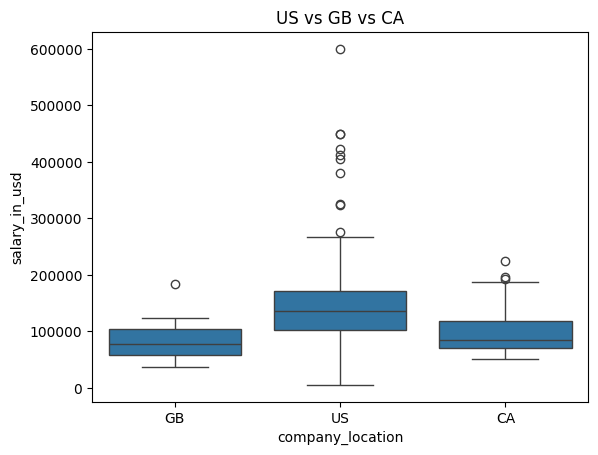

In [76]:
df_filtered = df[df['company_location'].isin(['US', 'GB', 'CA'])]
sns.boxplot(
    data=df_filtered,
    x='company_location',
    y='salary_in_usd')
plt.title('US vs GB vs CA')
plt.show()

In [78]:
# All values are valid
x = df['remote_ratio'].isin([0,50,100]).all()
print("remote_ratio all valid = {}".format(x))
x = df['experience_level'].isin(['EN', 'MI', 'SE', 'EX']).all()
print("experience_level all valid = {}".format(x))
x = df['company_size'].isin(['S', 'M', 'L']).all()
print("company_size all valid = {}".format(x))

remote_ratio all valid = True
experience_level all valid = True
company_size all valid = True


In [81]:
# Let's get the list of fully remote workers for US companies
working_remotely_for_us = df[(df['company_location'] == 'US') & (df['remote_ratio'] == 100) & (df['employee_residence'] != 'US')]
working_remotely_for_us[['salary_in_usd', 'employee_residence', 'job_title']]

,salary_in_usd,employee_residence,job_title
19,56000,PT,Lead Data Engineer
32,68428,GR,Data Scientist
40,45760,PH,Data Scientist
61,130800,ES,Data Engineer
73,150000,IN,BI Data Analyst
89,80000,BG,Data Analyst
99,95746,DE,Computer Vision Software Engineer
132,38400,VN,Applied Machine Learning Scientist
149,160000,BR,Cloud Data Engineer
179,5679,IN,Data Scientist


In [82]:
# Total count of foreign workers for US = 20
working_remotely_for_us.shape

(16, 10)

In [83]:
# Count of each job title
working_remotely_for_us['job_title'].value_counts()

,count
job_title,
Data Scientist,5
Applied Machine Learning Scientist,2
Lead Data Engineer,1
Data Engineer,1
BI Data Analyst,1
Data Analyst,1
Computer Vision Software Engineer,1
Cloud Data Engineer,1
Research Scientist,1


In [85]:
# Let's group by job_title
X_COL = ['salary_in_usd', 'employee_residence', 'job_title']
working_remotely_for_us.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False)

,salary_in_usd
job_title,
AI Scientist,"200,000"
Head of Data,"200,000"
Cloud Data Engineer,"160,000"
BI Data Analyst,"150,000"
Data Engineer,"130,800"
Computer Vision Software Engineer,"95,746"
Data Analyst,"80,000"
Applied Machine Learning Scientist,"56,700"
Lead Data Engineer,"56,000"


In [86]:
cat_cols = df.select_dtypes(include='object').columns
cat_cardinality = df[cat_cols].nunique().sort_values(ascending=False)

print('Categorical column cardinality (unique values):')
print(cat_cardinality.to_string())

Categorical column cardinality (unique values):
employee_residence    55
company_location      49
job_title             48
salary_currency       17
experience_level       4
company_size           3


In [88]:
a = set(df['company_location'].unique())
b = set(df['employee_residence'].unique())

print("Common:", a & b)
print("Only in company_location:", a - b)
print("Only in employee_residence:", b - a)

Common: {'MT', 'CA', 'MX', 'AU', 'PT', 'VN', 'HN', 'GB', 'LU', 'EE', 'SG', 'IR', 'AE', 'GR', 'RO', 'BE', 'BR', 'IE', 'PK', 'US', 'TR', 'MD', 'CN', 'CZ', 'FR', 'SI', 'MY', 'RU', 'ES', 'IN', 'AT', 'NG', 'HU', 'HR', 'NL', 'NZ', 'CH', 'DE', 'CO', 'PL', 'CL', 'JP', 'KE', 'IQ', 'UA', 'IT', 'DK'}
Only in company_location: {'IL', 'AS'}
Only in employee_residence: {'AR', 'HK', 'BG', 'BO', 'RS', 'PR', 'PH', 'JE'}


In [223]:
df = df_copy

In [224]:
# WARNING: Changing the data frame
df = df[~df['company_location'].isin(['IL', 'AS'])]
df = df[~df['employee_residence'].isin(['AR', 'HK', 'BG', 'BO', 'RS', 'PR', 'PH', 'JE'])]

In [196]:
ct = pd.crosstab(df['company_location'], df['employee_residence'])
ct.sum(axis=1).sort_values(ascending=False)  # by company_location
ct.sum(axis=0).sort_values(ascending=False)  # by employee_residence
ct.stack()[ct.stack() > 0].sort_values(ascending=False)

company_location  employee_residence
US                US                    312
GB                GB                     43
CA                CA                     27
IN                IN                     23
DE                DE                     20
                                       ... 
US                MY                      1
                  RO                      1
                  RU                      1
                  VN                      1
VN                VN                      1
Length: 75, dtype: int64

In [197]:
df[df['company_location'] == 'US']['employee_residence'].value_counts()

,count
employee_residence,
US,312
IN,4
BR,2
GR,1
PT,1
ES,1
DE,1
HU,1
VN,1


In [225]:
is_abroad = df['employee_residence'] != df['company_location']
sum(is_abroad & (df['company_location'] == 'US'))  # check is correct

16

In [226]:
df_filtered = df[is_abroad].drop(columns=['employee_residence','salary'])
df_filtered.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,35,"2,021.057",0.639,"2,020","2,021","2,021","2,021","2,022"
salary_in_usd,35,"83,696.429","56,106.739","5,679","50,000","62,726","107,023.500","225,000"
remote_ratio,35,84.286,29.133,0,75,100,100,100


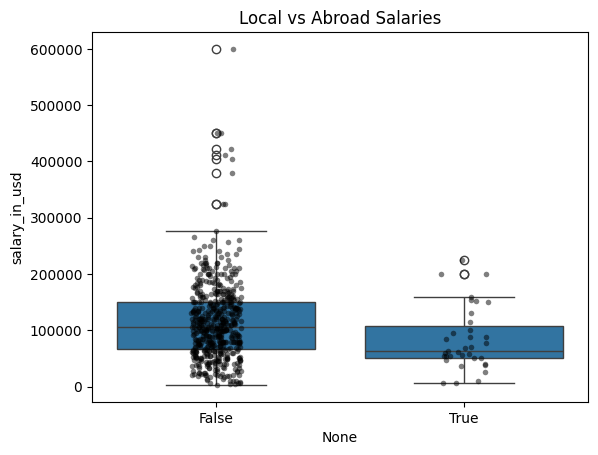

In [200]:
sns.boxplot(data=df, x=is_abroad, y='salary_in_usd')
sns.stripplot(data=df, x=is_abroad, y='salary_in_usd', color='black', alpha=0.5, size=4)
plt.title('Local vs Abroad Salaries')
plt.show()

In [227]:
df['is_abroad'] = is_abroad
df = df.drop(columns=['employee_residence'])

In [228]:
df_copy2 = df

In [229]:
df['company_location'].value_counts().head()

,count
company_location,
US,328
GB,46
CA,29
DE,24
IN,23


In [230]:
location_map = {
    'US': 'US', 'GB': 'GB', 'CA': 'CA', 'DE': 'DE', 'IN': 'IN', 'FR': 'FR', 'ES': 'ES', 'GR': 'GR',
    # Europe (other)
    'IT': 'Europe (other)', 'PT': 'Europe (other)', 'NL': 'Europe (other)', 'BE': 'Europe (other)',
    'CH': 'Europe (other)', 'AT': 'Europe (other)', 'PL': 'Europe (other)', 'RO': 'Europe (other)',
    'CZ': 'Europe (other)', 'HU': 'Europe (other)', 'HR': 'Europe (other)', 'DK': 'Europe (other)',
    'EE': 'Europe (other)', 'SI': 'Europe (other)', 'LU': 'Europe (other)', 'IE': 'Europe (other)',
    'MT': 'Europe (other)', 'RU': 'Europe (other)', 'UA': 'Europe (other)', 'MD': 'Europe (other)',
    # Latin America
    'MX': 'Latin America', 'BR': 'Latin America', 'CO': 'Latin America', 'CL': 'Latin America',
    'HN': 'Latin America',
    # Middle East / Africa
    'AE': 'Mid East / Africa', 'IR': 'Mid East / Africa', 'IQ': 'Mid East / Africa',
    'TR': 'Mid East / Africa', 'NG': 'Mid East / Africa', 'KE': 'Mid East / Africa',
    # Asia
    'CN': 'Asia', 'JP': 'Asia', 'SG': 'Asia', 'MY': 'Asia', 'PK': 'Asia', 'VN': 'Asia',
    # AU & NZ
    'AU': 'AU & NZ', 'NZ': 'AU & NZ',
}

df['company_location'] = df['company_location'].map(location_map)

In [232]:
# Remove salary, salary_currency
df = df.drop(columns=['salary', 'salary_currency'])

In [244]:
df.to_pickle('clean_df.pkl')

In [245]:
df.to_csv('w1_ds_salaries_clean.csv')